## **Laboratório de Features — Experimentação NLP**

Notebook para experimentar combinações de features e ver o impacto imediato nos modelos.

**Como usar:** Alterar os parâmetros na secção **CONFIG** e correr tudo. Cada run treina
um modelo NumPy + um PyTorch e mostra os resultados lado a lado.

Feature groups disponíveis:
- **TF-IDF** (word n-grams) — tamanho do vocabulário ajustável
- **Métricas Base** (16) — burstiness, typos, entropy, TTR, perplexity, POS, etc.
- **Métricas Avançadas** (+8) — GLTR, function words, repetition distance, sentence length entropy

### ⚙️ **Configurações**

> Alterar estes parâmetros e fazer **Run All** para testar uma combinação diferente.

In [11]:
# ⚙️ Configurações gerais
TFIDF_VOCAB_SIZE   = 10    # Nº de palavras no vocabulário TF-IDF (50, 500, 1500, 3000)
USE_BASIC_METRICS  = True    # 16 métricas base (burstiness, typos, entropy, etc.)
USE_ADVANCED       = False   # +8 métricas avançadas (GLTR, function words, etc.)

# ⚙️  Configuração de treino

EPOCHS_NUMPY   = 200
EPOCHS_PYTORCH = 150
BATCH_SIZE     = 32
LR_NUMPY       = 0.005
LR_PYTORCH     = 0.001
WEIGHT_DECAY   = 1e-4
PATIENCE       = 20

# ⚙️  Configurações de dados

CAMINHO_DATASET = '../data/dataset.csv'
CAMINHO_TESTE   = '../data/raw/dataset-exemplos.csv'
SEPARADOR       = ';'
SPLIT_TRAIN     = 0.70
SPLIT_VAL       = 0.15  

n_metrics = 16 if not USE_ADVANCED else 24
print(f"Config: TF-IDF={TFIDF_VOCAB_SIZE} + {n_metrics} métricas = ~{TFIDF_VOCAB_SIZE + n_metrics} features")

Config: TF-IDF=10 + 16 métricas = ~26 features


### **1. Imports**

In [12]:
import math, re, time, os, sys
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from spellchecker import SpellChecker
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sys.path.append(os.path.abspath('../src'))
from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
sns.set_style("whitegrid")

Dispositivo: cuda


### **2. Extrator de Features**

In [13]:
class TextFeatureExtractor:
    """
    Extrai TF-IDF + métricas comportamentais configuráveis.
    
    Métricas Base (16):
        burstiness, typos, word_entropy, TTR, avg_word_len, avg_sent_len,
        buzzword_ratio, adj_ratio, punct_ratio, bigram_ratio, trigram_density,
        perplexity, POS_entropy, rhythm_var, stopword_ratio, rare_ratio
    
    Métricas Avançadas (+8):
        function_word_ratio, function_word_entropy, repetition_distance,
        sentence_length_entropy, GLTR_top10, GLTR_top100, GLTR_top1000, GLTR_rest
    """
    def __init__(self, max_vocab=1500, use_basic=True, use_advanced=True):
        self.max_vocab = max_vocab
        self.use_basic = use_basic
        self.use_advanced = use_advanced
        self.spell = SpellChecker()
        self.vocab = None
        self.idf = None
        
        self.unigram_counts = Counter()
        self.bigram_counts = Counter()
        self.bigram_ranks = {}
        
        self.stopwords = set(stopwords.words("english"))
        self.LLM_BUZZWORDS = {
            'furthermore','moreover','delve','tapestry',
            'testament','pivotal','underscore','multifaceted',
            'crucial','consequently'
        }
        self.FUNCTION_WORDS = {
            'the','of','to','and','a','in','that','is','it','for','on','with',
            'as','at','this','by','from','or','an','be','are','was','were'
        }
        
        # Contar quantas métricas vamos gerar
        self.n_metrics = 0
        if use_basic: self.n_metrics += 16
        if use_advanced: self.n_metrics += 8

    def _get_gltr_metrics(self, words):
        if len(words) < 2 or not self.bigram_ranks:
            return 0, 0, 0, 0
        bigrams = list(zip(words, words[1:]))
        top_10 = top_100 = top_1000 = rest = 0
        for w1, w2 in bigrams:
            rank = self.bigram_ranks.get((w1, w2), None)
            if rank is None: rest += 1
            elif rank <= 10: top_10 += 1
            elif rank <= 100: top_100 += 1
            elif rank <= 1000: top_1000 += 1
            else: rest += 1
        total = len(bigrams)
        return top_10/total, top_100/total, top_1000/total, rest/total

    def _get_metrics(self, text):
        sentences = sent_tokenize(text)
        raw_tokens = word_tokenize(text)
        words = [w.lower() for w in raw_tokens if w.isalpha()]
    
        if not words:
            return [0] * self.n_metrics
    
        features = []
        
        if self.use_basic:
            s_lengths = [len(word_tokenize(s)) for s in sentences]
            burst = np.std(s_lengths) if len(sentences) > 1 else 0
            typos = len(self.spell.unknown(words)) / len(words)
            counts = Counter(words)
            total = len(words)
            ent = sum(-(c/total)*math.log2(c/total) for c in counts.values())
            ttr_val = len(set(words))/len(words)
            awl = np.mean([len(w) for w in words])
            asl = len(words)/len(sentences) if sentences else 0
            buzz = sum(w in self.LLM_BUZZWORDS for w in words)/len(words)
            
            tags = nltk.pos_tag(raw_tokens)
            adj = sum(tag.startswith('JJ') for _,tag in tags)/len(raw_tokens) if raw_tokens else 0
            punct = (text.count('!') + text.count('?') + text.count('...')) / len(text) if text else 0
        
            bigrams = list(zip(words, words[1:]))
            unique_bigrams = len(set(bigrams))
            bigram_ratio = unique_bigrams / len(bigrams) if bigrams else 0
            text_clean = text.replace(" ", "_")
            char_trigrams = [text_clean[i:i+3] for i in range(len(text_clean)-2)]
            char_trigram_density = len(set(char_trigrams)) / len(char_trigrams) if char_trigrams else 0
        
            unigram_counts = Counter(words)
            bigram_counts_local = Counter(bigrams)
            log_prob_sum = 0
            N = len(bigrams)
            for w1, w2 in bigrams:
                p = (bigram_counts_local[(w1,w2)] + 1) / (unigram_counts[w1] + len(unigram_counts))
                log_prob_sum += math.log2(p)
            perplexity = 2 ** (-log_prob_sum / N) if N > 0 else 0
        
            pos_tags = [tag for _,tag in tags]
            pos_counts = Counter(pos_tags)
            pos_total = len(pos_tags)
            pos_entropy = sum(-(c/pos_total)*math.log2(c/pos_total) for c in pos_counts.values())
        
            rhythm_var = np.var(s_lengths) if len(s_lengths) > 1 else 0
            stop_ratio = sum(w in self.stopwords for w in words)/len(words)
            rare_words = [w for w,c in counts.items() if c == 1]
            rare_ratio = len(rare_words)/len(words)
            
            features.extend([
                burst, typos, ent, ttr_val, awl, asl, buzz, adj, punct,
                bigram_ratio, char_trigram_density, perplexity, pos_entropy,
                rhythm_var, stop_ratio, rare_ratio
            ])
        
        if self.use_advanced:
            if not self.use_basic:
                # Preciso de recalcular variáveis base para as avançadas
                words = [w.lower() for w in raw_tokens if w.isalpha()]
                sentences = sent_tokenize(text)
                s_lengths = [len(word_tokenize(s)) for s in sentences]
                counts = Counter(words)
                
            fw = [w for w in words if w in self.FUNCTION_WORDS]
            fw_ratio = len(fw) / len(words)
            if fw:
                fw_counts = Counter(fw)
                fw_total = len(fw)
                fw_entropy = sum(-(c/fw_total)*math.log2(c/fw_total) for c in fw_counts.values())
            else:
                fw_entropy = 0
                
            last_seen = {}
            distances = []
            for i, w in enumerate(words):
                if w in last_seen:
                    distances.append(i - last_seen[w])
                last_seen[w] = i
            rep_distance = np.mean(distances) if distances else 0
            
            if s_lengths:
                sl_counts = Counter(s_lengths)
                sl_total = len(s_lengths)
                sl_entropy = sum(-(c/sl_total)*math.log2(c/sl_total) for c in sl_counts.values())
            else:
                sl_entropy = 0
                
            gltr_top10, gltr_top100, gltr_top1000, gltr_rest = self._get_gltr_metrics(words)
        
            features.extend([
                fw_ratio, fw_entropy, rep_distance, sl_entropy,
                gltr_top10, gltr_top100, gltr_top1000, gltr_rest
            ])
    
        return features

    def fit_tfidf(self, corpus):
        tokenized = [re.findall(r'\b[a-zA-Z]+\b', doc.lower()) for doc in corpus]
        doc_freq = Counter()
        for doc in tokenized:
            for word in set(doc):
                doc_freq[word] += 1
            self.unigram_counts.update(doc)
            self.bigram_counts.update(zip(doc, doc[1:]))
            
        self.vocab = [w for w, _ in doc_freq.most_common(self.max_vocab)]
        N = len(corpus)
        self.idf = {w: math.log((1+N)/(1+doc_freq[w])) + 1 for w in self.vocab}
        
        # Bigram ranks para GLTR
        following_dict = defaultdict(list)
        for (w1, w2), count in self.bigram_counts.items():
            following_dict[w1].append((w2, count))
        self.bigram_ranks = {}
        for w1, following in following_dict.items():
            following.sort(key=lambda x: x[1], reverse=True) 
            for rank, (w2, count) in enumerate(following):
                self.bigram_ranks[(w1, w2)] = rank + 1

    def transform_tfidf(self, corpus):
        matrix = []
        for doc in corpus:
            words = re.findall(r'\b[a-zA-Z]+\b', doc.lower())
            tf = Counter(words)
            length = len(words) if words else 1
            row = [(tf.get(w, 0)/length) * self.idf[w] for w in self.vocab]
            matrix.append(row)
        return np.array(matrix)

    def fit_transform(self, corpus):
        corpus = [str(t) for t in corpus]
        self.fit_tfidf(corpus)
        tfidf_matrix = self.transform_tfidf(corpus)
        
        if self.use_basic or self.use_advanced:
            behavioral_matrix = np.array([self._get_metrics(t) for t in corpus])
        else:
            behavioral_matrix = np.empty((len(corpus), 0))
            
        return tfidf_matrix, behavioral_matrix

    def transform(self, corpus):
        """Transforma novos textos (sem re-fit)."""
        corpus = [str(t) for t in corpus]
        tfidf_matrix = self.transform_tfidf(corpus)
        
        if self.use_basic or self.use_advanced:
            behavioral_matrix = np.array([self._get_metrics(t) for t in corpus])
        else:
            behavioral_matrix = np.empty((len(corpus), 0))
            
        return tfidf_matrix, behavioral_matrix

### **3. Carregar e Preparar Dados**

In [14]:
print("A carregar dataset...")
df = pd.read_csv(CAMINHO_DATASET, sep=SEPARADOR).dropna()
df.columns = df.columns.str.strip().str.lower()

# Extrair features
extractor = TextFeatureExtractor(
    max_vocab=TFIDF_VOCAB_SIZE,
    use_basic=USE_BASIC_METRICS,
    use_advanced=USE_ADVANCED
)

print(f"A extrair TF-IDF ({TFIDF_VOCAB_SIZE}) + {extractor.n_metrics} métricas...")
t0 = time.time()
X_tfidf, X_extra = extractor.fit_transform(df["text"])
print(f"Extração concluída em {time.time()-t0:.1f}s")

# Normalizar métricas comportamentais
scaler = StandardScaler()
if X_extra.shape[1] > 0:
    X_extra_norm = scaler.fit_transform(X_extra)
    X_combined = np.hstack((X_tfidf, X_extra_norm))
else:
    X_combined = X_tfidf

# Encoding
labels_list = df['label'].unique()
label_to_idx = {l: i for i, l in enumerate(labels_list)}
Y_indices = np.array([label_to_idx[l] for l in df['label']])
Y_onehot = np.zeros((len(Y_indices), len(labels_list)))
Y_onehot[np.arange(len(Y_indices)), Y_indices] = 1

# Split estratificado
np.random.seed(42)
idx = np.arange(len(X_combined))
np.random.shuffle(idx)
X_s, Y_s, Y_idx_s = X_combined[idx], Y_onehot[idx], Y_indices[idx]

train_end = int(len(X_s) * SPLIT_TRAIN)
val_end = int(len(X_s) * (SPLIT_TRAIN + SPLIT_VAL))

X_train, Y_train, y_train = X_s[:train_end], Y_s[:train_end], Y_idx_s[:train_end]
X_val, Y_val, y_val = X_s[train_end:val_end], Y_s[train_end:val_end], Y_idx_s[train_end:val_end]
X_test, Y_test, y_test = X_s[val_end:], Y_s[val_end:], Y_idx_s[val_end:]

print(f"\n✅ Features: {X_combined.shape[1]} ({X_tfidf.shape[1]} TF-IDF + {X_extra.shape[1]} métricas)")
print(f"   Treino: {X_train.shape[0]} | Val: {X_val.shape[0]} | Teste: {X_test.shape[0]}")
print(f"   Classes: {list(labels_list)}")

A carregar dataset...
A extrair TF-IDF (10) + 16 métricas...
Extração concluída em 22.1s

✅ Features: 26 (10 TF-IDF + 16 métricas)
   Treino: 1750 | Val: 375 | Teste: 375
   Classes: ['Anthropic', 'Meta', 'Google', 'OpenAI', 'Human']


### **4. Treino — Modelo NumPy**

In [15]:
print("A treinar modelo NumPy...")
np.random.seed(42)

adam_opt = Adam(learning_rate=LR_NUMPY)
numpy_model = NeuralNetwork(loss_func=CategoricalCrossEntropy())

numpy_model.add(DenseLayer(X_train.shape[1], 128, optimizer=adam_opt))
numpy_model.add(ReLUActivation())
numpy_model.add(DropoutLayer(rate=0.3))
numpy_model.add(DenseLayer(128, 64, optimizer=adam_opt))
numpy_model.add(ReLUActivation())
numpy_model.add(DenseLayer(64, len(labels_list), optimizer=adam_opt))
numpy_model.add(SoftmaxActivation())

t0 = time.time()
numpy_model.fit(
    X_train, Y_train,
    epochs=EPOCHS_NUMPY,
    batch_size=BATCH_SIZE,
    verbose=True,
    X_val=X_val, Y_val=Y_val,
    patience=PATIENCE
)
tempo_np = time.time() - t0

np_train_loss, np_train_acc = numpy_model.evaluate(X_train, Y_train)
np_val_loss, np_val_acc = numpy_model.evaluate(X_val, Y_val)
np_test_loss, np_test_acc = numpy_model.evaluate(X_test, Y_test)

print(f"\nNumPy — Treino: {np_train_acc:.2%} | Val: {np_val_acc:.2%} | Teste: {np_test_acc:.2%} ({tempo_np:.1f}s)")

A treinar modelo NumPy...
Epoch 1/200 | Loss: 1.1042 | Val Loss: 1.2386 | Train Acc: 55.31% | Val Acc: 50.67%
Epoch 11/200 | Loss: 0.7890 | Val Loss: 1.0706 | Train Acc: 69.66% | Val Acc: 58.40%
Epoch 21/200 | Loss: 0.6636 | Val Loss: 1.1896 | Train Acc: 74.17% | Val Acc: 56.53%
Epoch 31/200 | Loss: 0.5476 | Val Loss: 1.3604 | Train Acc: 79.77% | Val Acc: 53.07%

Early Stopping na epoca 31! Val Loss nao melhorou ha 20 epocas.
Melhor Val Loss: 1.0706
Melhores pesos restaurados.

NumPy — Treino: 69.66% | Val: 58.40% | Teste: 56.00% (1.5s)


### **5. Treino — Modelo PyTorch**

In [16]:
print("A treinar modelo PyTorch...")
torch.manual_seed(42)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True
)

class DetectorIA(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

model = DetectorIA(X_train.shape[1], len(labels_list)).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR_PYTORCH, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history_pt = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0
best_state = None

t0 = time.time()
for epoch in range(EPOCHS_PYTORCH):
    model.train()
    batch_losses = []
    for bX, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bX), by)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    avg_train = np.mean(batch_losses)
    history_pt['train_loss'].append(avg_train)
    
    model.eval()
    with torch.no_grad():
        val_out = model(X_val_t)
        val_loss = criterion(val_out, y_val_t).item()
        val_acc = (torch.argmax(val_out, 1) == y_val_t).float().mean().item()
    
    history_pt['val_loss'].append(val_loss)
    history_pt['val_acc'].append(val_acc)
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    
    if (epoch+1) % 10 == 0:
        print(f"  Época {epoch+1:3d}/{EPOCHS_PYTORCH} | Train: {avg_train:.4f} | Val: {val_loss:.4f} | Val Acc: {val_acc:.2%}")
    
    if patience_counter >= PATIENCE:
        print(f"  Early Stopping na época {epoch+1}!")
        break

if best_state: model.load_state_dict(best_state)
tempo_pt = time.time() - t0

model.eval()
with torch.no_grad():
    pt_train_acc = (torch.argmax(model(X_train_t), 1) == y_train_t).float().mean().item()
    pt_val_acc = (torch.argmax(model(X_val_t), 1) == y_val_t).float().mean().item()
    pt_test_acc = (torch.argmax(model(X_test_t), 1) == y_test_t).float().mean().item()

print(f"\nPyTorch — Treino: {pt_train_acc:.2%} | Val: {pt_val_acc:.2%} | Teste: {pt_test_acc:.2%} ({tempo_pt:.1f}s)")

A treinar modelo PyTorch...
  Época  10/150 | Train: 1.0950 | Val: 1.0896 | Val Acc: 55.73%
  Época  20/150 | Train: 1.0396 | Val: 1.0516 | Val Acc: 55.47%
  Época  30/150 | Train: 0.9916 | Val: 1.0413 | Val Acc: 56.53%
  Época  40/150 | Train: 0.9993 | Val: 1.0303 | Val Acc: 57.07%
  Época  50/150 | Train: 0.9683 | Val: 1.0207 | Val Acc: 58.40%
  Época  60/150 | Train: 0.9264 | Val: 1.0238 | Val Acc: 58.13%
  Época  70/150 | Train: 0.9419 | Val: 1.0286 | Val Acc: 58.93%
  Época  80/150 | Train: 0.9236 | Val: 1.0256 | Val Acc: 57.60%
  Early Stopping na época 89!

PyTorch — Treino: 69.89% | Val: 58.40% | Teste: 58.13% (26.6s)


### **6. Resultados Comparativos**

Modelo                    Train        Val      Teste      Tempo
-----------------------------------------------------------------
NumPy                   69.66%    58.40%    56.00%       1.5s
PyTorch                 69.89%    58.40%    58.13%      26.6s

Config: TF-IDF=10 | Basic=True | Advanced=False | Total=26 features


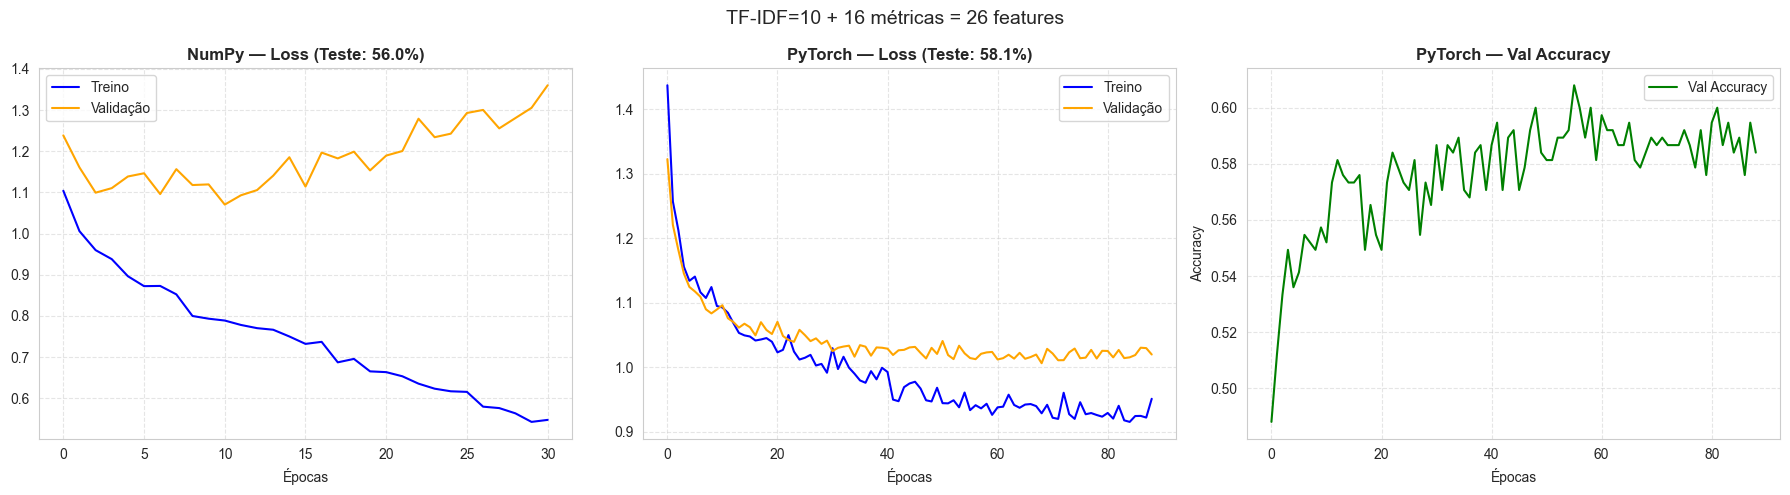

In [17]:
# Tabela
print("=" * 65)
print(f"{'Modelo':<20} {'Train':>10} {'Val':>10} {'Teste':>10} {'Tempo':>10}")
print("-" * 65)
print(f"{'NumPy':<20} {np_train_acc:>9.2%} {np_val_acc:>9.2%} {np_test_acc:>9.2%} {tempo_np:>9.1f}s")
print(f"{'PyTorch':<20} {pt_train_acc:>9.2%} {pt_val_acc:>9.2%} {pt_test_acc:>9.2%} {tempo_pt:>9.1f}s")
print("=" * 65)
print(f"\nConfig: TF-IDF={TFIDF_VOCAB_SIZE} | Basic={USE_BASIC_METRICS} | Advanced={USE_ADVANCED} | Total={X_combined.shape[1]} features")

# Curvas de aprendizagem
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(numpy_model.history['loss'], label='Treino', color='blue')
axes[0].plot(numpy_model.history['val_loss'], label='Validação', color='orange')
axes[0].set_title(f'NumPy — Loss (Teste: {np_test_acc:.1%})', fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(history_pt['train_loss'], label='Treino', color='blue')
axes[1].plot(history_pt['val_loss'], label='Validação', color='orange')
axes[1].set_title(f'PyTorch — Loss (Teste: {pt_test_acc:.1%})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(history_pt['val_acc'], label='Val Accuracy', color='green')
axes[2].set_title('PyTorch — Val Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

for ax in axes: ax.set_xlabel('Épocas')
plt.suptitle(f'TF-IDF={TFIDF_VOCAB_SIZE} + {extractor.n_metrics} métricas = {X_combined.shape[1]} features', fontsize=14)
plt.tight_layout()
plt.show()

### **7. Teste** 

A carregar dataset de teste...

  NumPy:   46.40%
  PyTorch: 50.40%


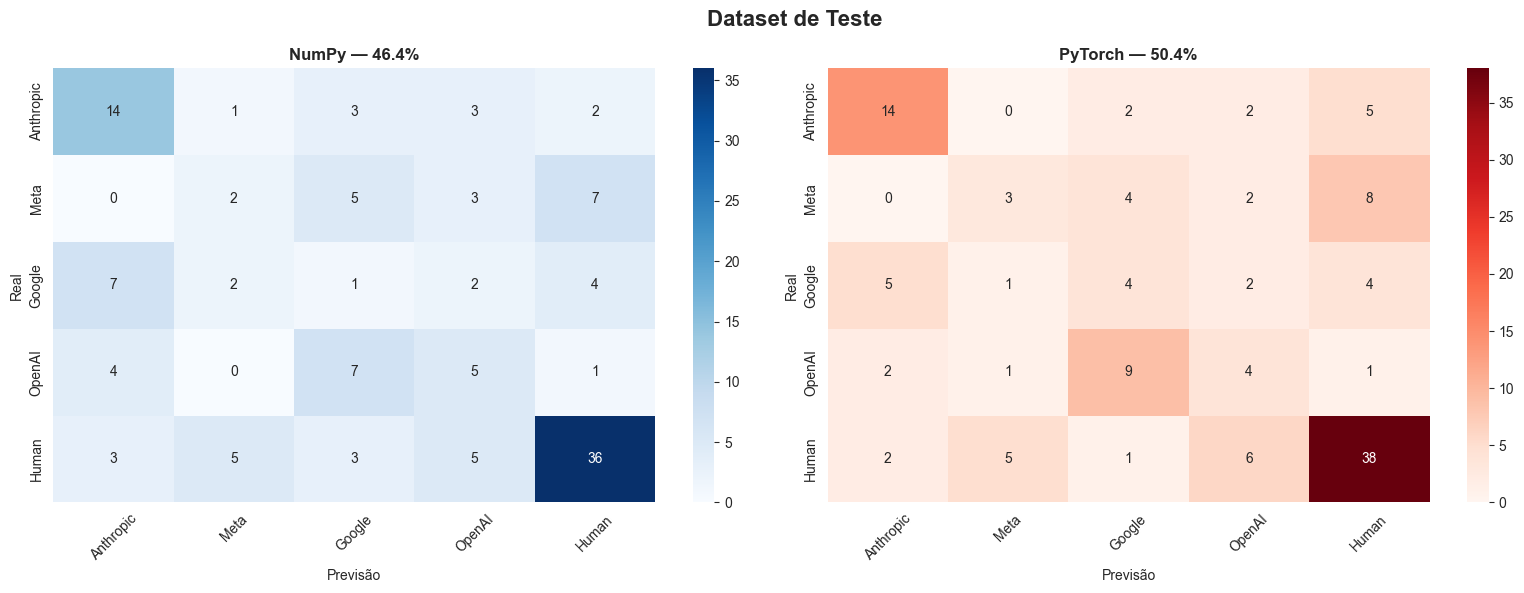


Classification Report — PyTorch:
              precision    recall  f1-score   support

   Anthropic       0.61      0.61      0.61        23
        Meta       0.30      0.18      0.22        17
      Google       0.20      0.25      0.22        16
      OpenAI       0.25      0.24      0.24        17
       Human       0.68      0.73      0.70        52

    accuracy                           0.50       125
   macro avg       0.41      0.40      0.40       125
weighted avg       0.49      0.50      0.50       125



In [18]:
if os.path.exists(CAMINHO_TESTE):
    print("A carregar dataset de teste...")
    df_new = pd.read_csv(CAMINHO_TESTE, sep=SEPARADOR).dropna()
    df_new.columns = df_new.columns.str.strip().str.lower()
    
    # Detetar coluna de texto
    col_texto = next((c for c in ['text','texto','content'] if c in df_new.columns), None)
    if col_texto is None:
        col_texto = next(c for c in df_new.columns if df_new[c].dtype == object)
    
    corpus_new = [str(t) for t in df_new[col_texto]]
    
    # Transformar com o mesmo extractor (sem re-fit!)
    X_tfidf_new, X_extra_new = extractor.transform(corpus_new)
    if X_extra_new.shape[1] > 0:
        X_extra_scaled = scaler.transform(X_extra_new)
        X_new = np.hstack((X_tfidf_new, X_extra_scaled))
    else:
        X_new = X_tfidf_new
    
    # NumPy
    y_pred_np = np.argmax(numpy_model.predict(X_new), axis=1)
    
    # PyTorch
    model.eval()
    with torch.no_grad():
        X_new_t = torch.FloatTensor(X_new).to(device)
        y_pred_pt = torch.argmax(model(X_new_t), 1).cpu().numpy()
    
    # Se houver labels
    col_label = next((c for c in ['label','labels','class'] if c in df_new.columns), None)
    
    if col_label:
        # Mapear labels (capitalização)
        mapa = {str(c).lower(): c for c in labels_list}
        df_new[col_label] = df_new[col_label].apply(lambda x: mapa.get(str(x).lower(), x))
        y_true = np.array([label_to_idx[l] for l in df_new[col_label]])
        
        acc_np = np.mean(y_pred_np == y_true) * 100
        acc_pt = np.mean(y_pred_pt == y_true) * 100
        
        print(f"\n{'='*50}")
        print(f"  NumPy:   {acc_np:.2f}%")
        print(f"  PyTorch: {acc_pt:.2f}%")
        print(f"{'='*50}")
        
        # Matrizes de confusão
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        cm_np = confusion_matrix(y_true, y_pred_np)
        sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels_list, yticklabels=labels_list, ax=axes[0])
        axes[0].set_title(f'NumPy — {acc_np:.1f}%', fontweight='bold')
        
        cm_pt = confusion_matrix(y_true, y_pred_pt)
        sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Reds',
                    xticklabels=labels_list, yticklabels=labels_list, ax=axes[1])
        axes[1].set_title(f'PyTorch — {acc_pt:.1f}%', fontweight='bold')
        
        for ax in axes:
            ax.set_xlabel('Previsão'); ax.set_ylabel('Real')
            ax.tick_params(axis='x', rotation=45)
        
        plt.suptitle('Dataset de Teste', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print("\nClassification Report — PyTorch:")
        print(classification_report(y_true, y_pred_pt, target_names=labels_list, zero_division=0))
    else:
        # Sem labels — mostrar previsões
        print(f"\n📋 Previsões ({len(corpus_new)} textos):")
        for i in range(min(10, len(corpus_new))):
            print(f"  {corpus_new[i][:50]}... → NP: {labels_list[y_pred_np[i]]} | PT: {labels_list[y_pred_pt[i]]}")
else:
    print(f"Ficheiro '{CAMINHO_TESTE}' não encontrado — secção ignorada.")

### **8. Guia Rápido de Experimentação**

Combinações sugeridas para testar:

| Experiência | `TFIDF_VOCAB_SIZE` | `USE_BASIC` | `USE_ADVANCED` | Features |
|---|---|---|---|---|
| Só métricas (sem TF-IDF) | `0`* | `True` | `True` | 24 |
| TF-IDF light | `50` | `True` | `False` | 66 |
| TF-IDF medium | `500` | `True` | `True` | 524 |
| TF-IDF full | `1500` | `True` | `True` | 1524 |
| TF-IDF heavy | `3000` | `True` | `True` | 3024 |
| Só TF-IDF | `1500` | `False` | `False` | 1500 |

*Para `TFIDF_VOCAB_SIZE=0`, definir `max_vocab=1` no extractor (mínimo).

Após cada experiência, comparar a accuracy no teste do professor para decidir.